In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [12]:
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target)

In [13]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [14]:
knn = KNeighborsClassifier(n_neighbors=5,weights='distance')
knn.fit(X_train_s,y_train)
acc = accuracy_score(y_test,knn.predict(X_test_s))
print("KNN (k=5) test accuracy:", round(acc, 4))

KNN (k=5) test accuracy: 0.9561


In [15]:
#Without getting scaled
knn_ns = KNeighborsClassifier(n_neighbors=5,weights='distance').fit(X_train, y_train)
acc_ns = accuracy_score(y_test, knn_ns.predict(X_test))
print("KNN (k=5) UNSCALED     :", round(acc_ns, 4))

KNN (k=5) UNSCALED     : 0.9123


Best k by cross-validation: 8 | CV acc: 0.9714


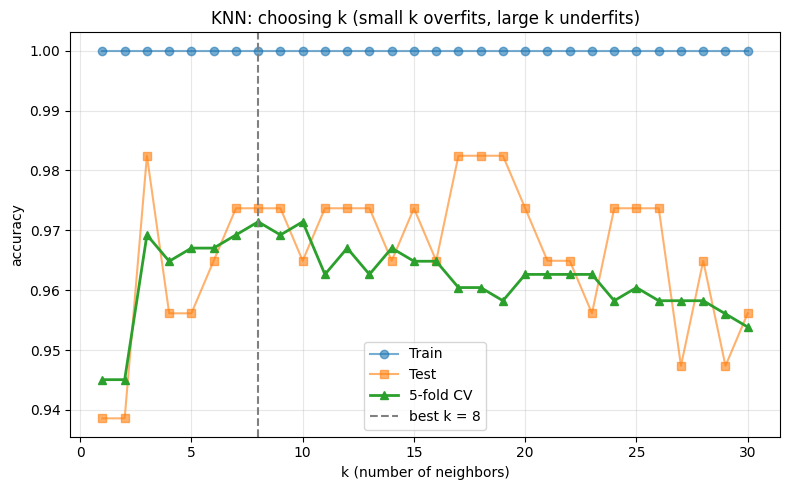

In [19]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score

ks = range(1, 31)
train_acc, test_acc, cv_acc = [], [], []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k,weights='distance').fit(X_train_s, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train_s)))
    test_acc.append(accuracy_score(y_test,  knn.predict(X_test_s)))
    cv_acc.append(cross_val_score(knn, X_train_s, y_train, cv=5).mean())  # proper way to pick k


best_k = ks[int(np.argmax(cv_acc))]
print("Best k by cross-validation:", best_k, "| CV acc:", round(max(cv_acc), 4))

plt.figure(figsize=(8,5))
plt.plot(ks, train_acc, 'o-', label='Train', alpha=0.6)
plt.plot(ks, test_acc,  's-', label='Test',  alpha=0.6)
plt.plot(ks, cv_acc,    '^-', label='5-fold CV', linewidth=2)
plt.axvline(best_k, color='gray', ls='--', label=f'best k = {best_k}')
plt.xlabel('k (number of neighbors)'); plt.ylabel('accuracy')
plt.title('KNN: choosing k (small k overfits, large k underfits)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('knn_k.png', dpi=110); plt.show()